In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print("✅ All libraries loaded successfully!")
print("Ready to build ML project!")

✅ All libraries loaded successfully!
Ready to build ML project!


In [8]:
# Data load karo
df = pd.read_csv('train.csv')

print("✅ Dataset Loaded Successfully!")
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")

✅ Dataset Loaded Successfully!

Shape: (1460, 81)

First 5 rows:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  Y

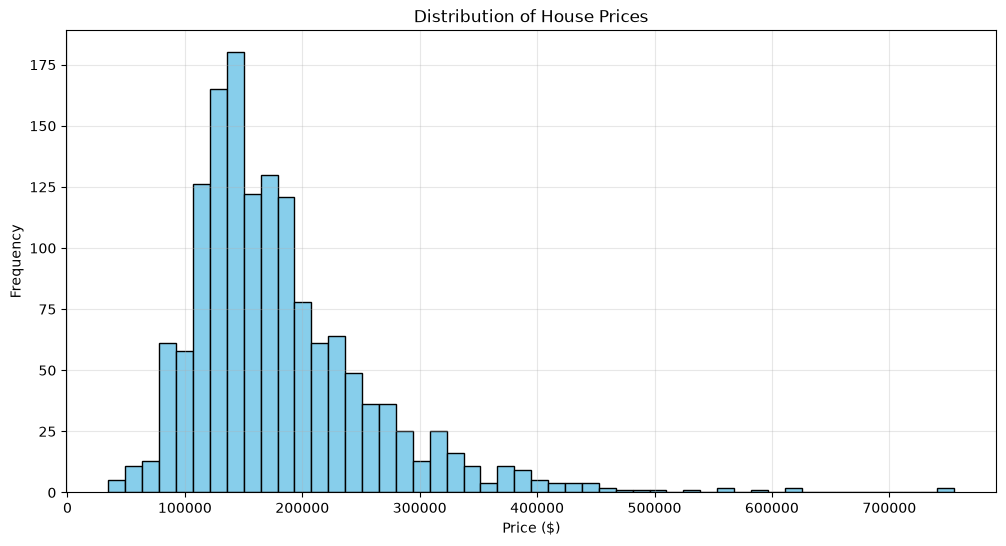


Price Range: $34,900 - $755,000
Average Price: $180,921


In [9]:
# Visualization
plt.figure(figsize=(12, 6))
plt.hist(df['SalePrice'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

print(f"\nPrice Range: ${df['SalePrice'].min():,.0f} - ${df['SalePrice'].max():,.0f}")
print(f"Average Price: ${df['SalePrice'].mean():,.0f}")

In [10]:
# Data Info dekho
print("Dataset Info:")
print(df.info())

print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*50)
print("Duplicate Rows:")
print(df.duplicated().sum())

print("\n" + "="*50)
print("Basic Statistics:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overa

In [11]:
# Correlation check - sabse important features
plt.figure(figsize=(12, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Housing Dataset')
plt.tight_layout()
plt.show()

# SalePrice ke saath highest correlation
print("\nTop 10 Features Correlated with SalePrice:")
print(correlation['SalePrice'].sort_values(ascending=False).head(10))

ValueError: could not convert string to float: 'RL'

<Figure size 1200x1000 with 0 Axes>

Calculating Correlation Matrix (numeric columns only)...


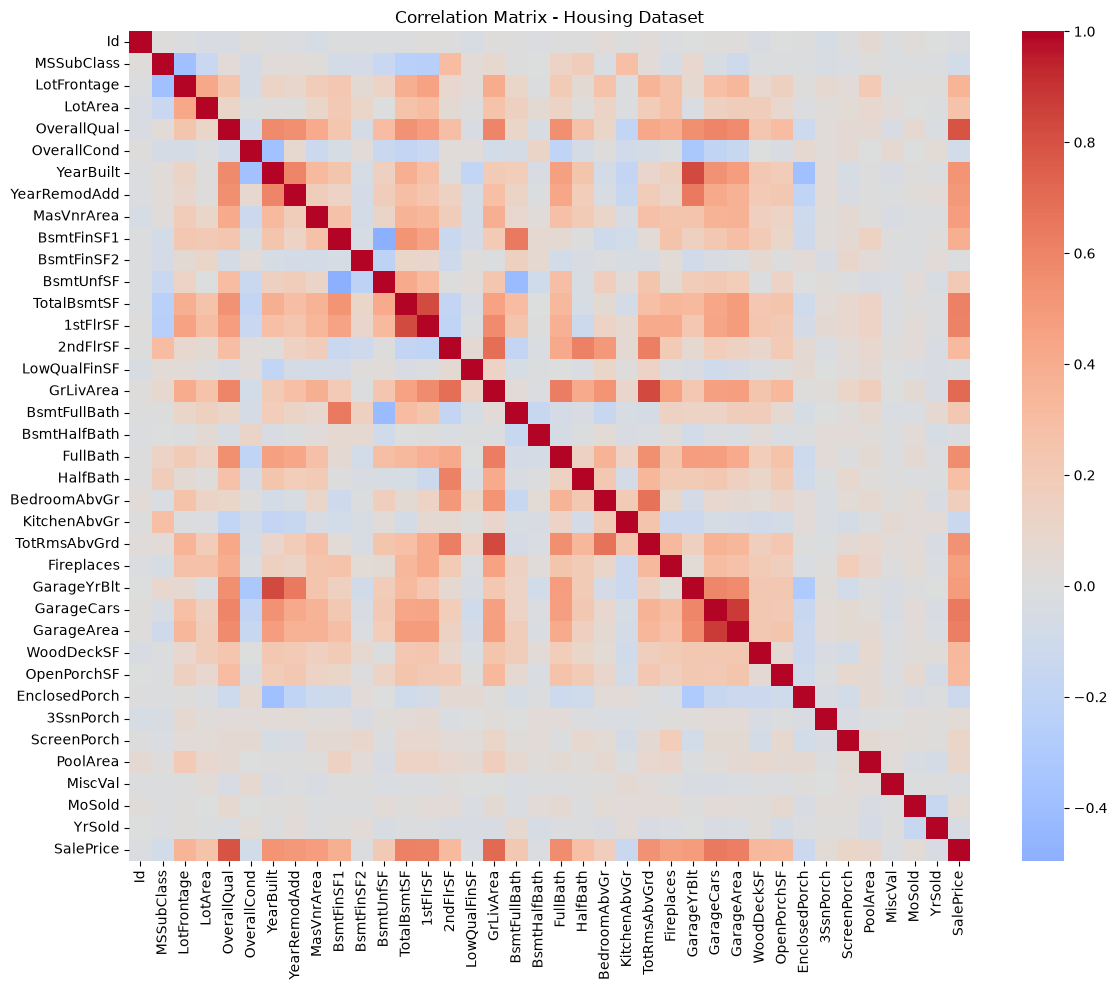


Top 10 Features Correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [12]:
# Correlation - sirf numeric columns
print("Calculating Correlation Matrix (numeric columns only)...")

plt.figure(figsize=(12, 10))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Housing Dataset')
plt.tight_layout()
plt.show()

print("\nTop 10 Features Correlated with SalePrice:")
print(correlation['SalePrice'].sort_values(ascending=False).head(10))

In [13]:
# Categorical columns ko drop kar do (ya encode kar sakte ho)
print("Data shape before cleaning:", df.shape)

# Sirf numeric columns rakh do correlation ke liye
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Missing values handle karo
for col in numeric_df.columns:
    if numeric_df[col].isnull().sum() > 0:
        numeric_df[col].fillna(numeric_df[col].mean(), inplace=True)

print("✅ Data cleaned!")
print(f"Shape after cleaning: {numeric_df.shape}")
print(f"Missing values: {numeric_df.isnull().sum().sum()}")
print(f"\nDataset Info:\n{numeric_df.head()}")

Data shape before cleaning: (1460, 81)
✅ Data cleaned!
Shape after cleaning: (1460, 38)
Missing values: 348

Dataset Info:
   Id  MSSubClass  LotFrontage  LotArea  OverallQual  OverallCond  YearBuilt  \
0   1          60         65.0     8450            7            5       2003   
1   2          20         80.0     9600            6            8       1976   
2   3          60         68.0    11250            7            5       2001   
3   4          70         60.0     9550            7            5       1915   
4   5          60         84.0    14260            8            5       2000   

   YearRemodAdd  MasVnrArea  BsmtFinSF1  ...  WoodDeckSF  OpenPorchSF  \
0          2003       196.0         706  ...           0           61   
1          1976         0.0         978  ...         298            0   
2          2002       162.0         486  ...           0           42   
3          1970         0.0         216  ...           0           35   
4          2000       350.0    

/var/folders/zl/7sg5kd6x5y90y_djwwqb78480000gn/T/ipykernel_2559/2409248080.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  numeric_df[col].fillna(numeric_df[col].mean(), inplace=True)


In [14]:
# Categorical columns ko drop kar do
print("Data shape before cleaning:", df.shape)

# Sirf numeric columns rakh do
numeric_df = df.select_dtypes(include=[np.number]).copy()

# Missing values handle karo (proper way)
for col in numeric_df.columns:
    if numeric_df[col].isnull().sum() > 0:
        numeric_df[col] = numeric_df[col].fillna(numeric_df[col].mean())

print("✅ Data cleaned!")
print(f"Shape after cleaning: {numeric_df.shape}")
print(f"Missing values: {numeric_df.isnull().sum().sum()}")

Data shape before cleaning: (1460, 81)
✅ Data cleaned!
Shape after cleaning: (1460, 38)
Missing values: 0


In [15]:
# Target aur Features separate kar
X = numeric_df.drop('SalePrice', axis=1)  # Features
y = numeric_df['SalePrice']  # Target

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n✅ Train set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data ready for modeling!")

Features: (1460, 37)
Target: (1460,)

✅ Train set: (1168, 37)
✅ Test set: (292, 37)
✅ Data ready for modeling!


In [16]:
# Model 1: Linear Regression
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_score = lr.score(X_test_scaled, y_test)
print(f"Linear Regression R² Score: {lr_score:.4f}")

# Model 2: Random Forest
print("\nTraining Random Forest...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_score = rf.score(X_test, y_test)
print(f"Random Forest R² Score: {rf_score:.4f}")

# Model 3: Gradient Boosting
print("\nTraining Gradient Boosting...")
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_score = gb.score(X_test, y_test)
print(f"Gradient Boosting R² Score: {gb_score:.4f}")

print("\n" + "="*50)
print("✅ All models trained successfully!")
print("="*50)

Training Linear Regression...
Linear Regression R² Score: 0.8227

Training Random Forest...
Random Forest R² Score: 0.8877

Training Gradient Boosting...
Gradient Boosting R² Score: 0.8974

✅ All models trained successfully!


In [17]:
# Best model se predictions
y_pred_gb = gb.predict(X_test)

# Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("="*50)
print("GRADIENT BOOSTING - DETAILED EVALUATION")
print("="*50)
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print("="*50)

# Actual vs Predicted comparison
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_gb[:10],
    'Difference': abs(y_test.values[:10] - y_pred_gb[:10])
})
print("\nFirst 10 Predictions vs Actual:")
print(comparison)

GRADIENT BOOSTING - DETAILED EVALUATION
Mean Absolute Error (MAE): $17,504.64
Root Mean Squared Error (RMSE): $28,053.06
R² Score: 0.8974

First 10 Predictions vs Actual:
   Actual      Predicted    Difference
0  154500  144299.162924  10200.837076
1  325000  335489.603615  10489.603615
2  115000  125608.994260  10608.994260
3  159000  157989.663694   1010.336306
4  315500  325604.349320  10104.349320
5   75500   83043.342991   7543.342991
6  311500  229250.724304  82249.275696
7  146000  143354.570639   2645.429361
8   84500   82891.937649   1608.062351
9  135500  137465.682302   1965.682302


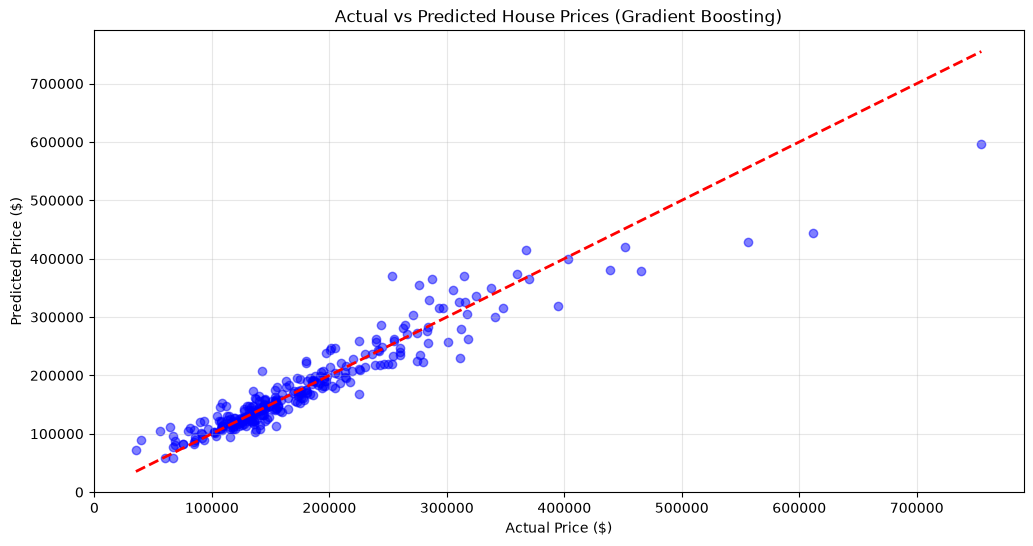

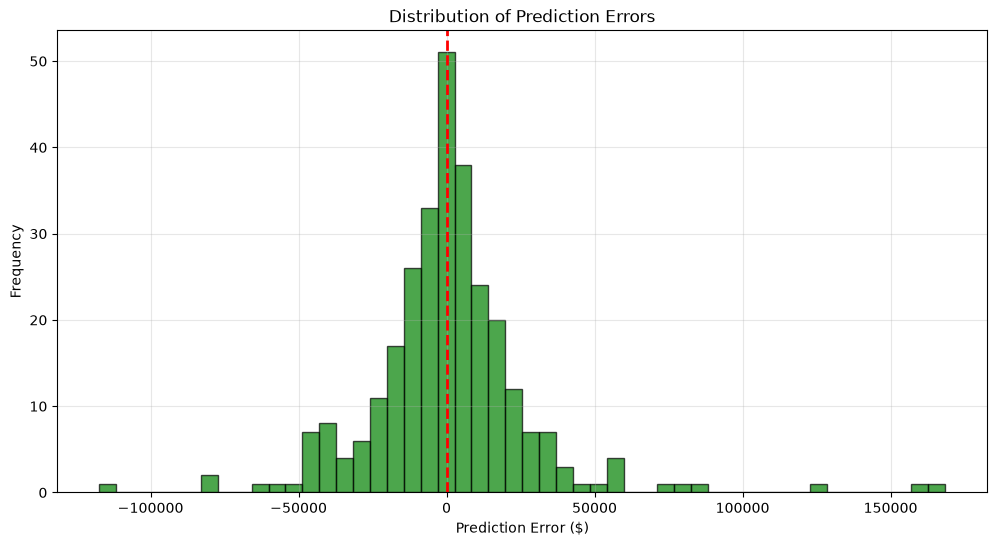

In [18]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted House Prices (Gradient Boosting)')
plt.grid(alpha=0.3)
plt.show()

# Residuals (errors)
residuals = y_test - y_pred_gb
plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=50, edgecolor='black', color='green', alpha=0.7)
plt.xlabel('Prediction Error ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.grid(alpha=0.3)
plt.show()

In [19]:
import pickle

# Save model
with open('housing_model.pkl', 'wb') as f:
    pickle.dump(gb, f)

print("✅ Model saved as 'housing_model.pkl'")

✅ Model saved as 'housing_model.pkl'
